# **Analise Seguro Auto - SUSEP**
---

Este notebook tem como principal intuito, realizar analises exploratorias e exercicitar a implementação de modelos de machine learning. Esta analise será mais desafiadora, se comparado com as analises com datasets baixados da Kaggle, pois eu não a disposição outros notebook para consulta/ estudo e ideias.

**Data Inicio: 07/01/2026**

- Fonte de dados: https://www.gov.br/susep/pt-br/central-de-conteudos/dados-estatisticos/bases-anonimizadas/bases_auto.
- Documento de estrutua dos arquivos 'S_AUTO', em PDF. Disponivel dentro da pasta raiz dessa analise.

---
## Dados do CSV:
- COD_APO        : Número inteiro que representa a seguradora e a apólice.
- COD_ENDOSSO    : Número inteiro que representa a seguradora, a apólice e o endosso.
- DATA_COMP      : Não disponivel na documentação/ Data de competência contábil (mês/ano em que o sinistro foi registrado)
- ITEM           : Preenchido com o item de identificação do veículo em caso de apólice coletiva. Caso contrário, preenchido com o valor “000000”. O número está alinhado à direita, e completado com zeros à esquerda.
- MODALIDADE     : Preenchido com o código correspondente à modalidade. Exemplo: VMR - Valor de Mercado Referenciado (1), VR - Valor Determinado (2), Produtos com uma única cobertura de RCF (3) e seguro popular (4).
- TIPO_PROD      : Preenchido com o código correspondente ao tipo de produto. Exemplo: Padrão (1) e Perfil (2).
- COBERTURA      : Preenchido com o tipo de cobertura contratada, de acordo com o código estabelecido na tabela III
- COD_MODELO     : Preenchido com o código do modelo do veículo na tabela FIPE(ver tabela 9). Caso o modelo não exista na tabela FIPE, preenchido com “999999-9”.
- ANO_MODELO     : Preenchido com o ano do modelo do veículo – AAAA 
- COD_TARIF      : Preenchido com o código da categoria tarifária em que o veículo se enquadra, conforme estabelecido na tabela IV
- REGIAO         : Preenchido com o código da região de risco, conforme estabelecido na tabela VIII.
- COD_CONT       : Preenchido com o código do tipo de contrato de seguro: 1 – Para valor de mercado referenciado (V. M. R.), 2 – Para valor definido (V. D.).
- EVENTO         : Preenchido com o código de sinistro de acordo com a tabela XI.
- INDENIZ        : Preenchido com o valor total da indenização efetivamente paga ao segurado, de acordo com o evento informado, sem desconto de cosseguro e/ou resseguro. Para o caso de sinistro avisado e não pago, preenchido com o valor estimado desta indenização.
- VAL_SALVAD     : Preenchido com o valor do salvado.
- D_SALVADO      : Preenchido com a data de recuperação do salvado, referente ao sinistro gerador do registro – AAAAMMDD. Caso não haja informação para este campo, preenchido com “00000000”.
- VAL_RESS       : Preencher com o valor do ressarcimento. 
- D_RESS         : Preenchido com a data de recuperação do ressarcimento, referente ao sinistro gerador do registro – AAAAMMDD. Caso não haja informação para este campo, preenchido com “00000000”.
- D_AVI          : Preenchido com a data do aviso do sinistro, de acordo com o evento informado –AAAAMMDD. Caso não haja informação para este campo, preenchido com “00000000”.
- D_LIQ          : Preenchido com a data de liquidação do sinistro, de acordo com o evento informado –AAAAMMDD. Obs.: Em caso de valor estimado, preenchido com “00000000”.
- D_OCORR        : Preenchido com a data de ocorrência do sinistro – AAAAMMDD.
- CAUSA          : Preenchido com o código da causa geradora do sinistro, conforme estabelecido na tabela V.
- SEXO           : Preenchido com a letra correspondente ao sexo do condutor sinistrado. Exemplo: Masculino (M); Feminino (F). No caso de produto do tipo Perfil, este campo serápreenchido com os códigos acima, caso contrário, este campo poderá estarpreenchido com ‘0’, na eventualidade da seguradora não possuir esse dado. 
- D_NASC         : Data de Nascimento do condutor sinistrado – AAAAMMDD. No caso de produto do tipo Perfil, este campo será preenchido com uma data válida, caso contrário, este campo poderá estarpreenchido com ‘00000000’, na eventualidade da seguradora não possuir esse dado.
- CEP            : Código de Endereçamento Postal da localidade de ocorrência do sinistro. No caso de produto do tipo Perfil, este campo será preenchido com um CEP válido, caso contrário, este campo poderá estar preenchido com ‘00000000’, na eventualidade da seguradora não possuir esse dado.

## Grupos:
- Caracteristicas do Seguro: COD_APO, COD_ENDOSSO, ITEM, MODALIDADE, TIPO_PROD
- Caracteristicas do Veiculo Segurado: COD_MODELO, ANO_MODELO
- Datas: D_SALVADO, D_RESS, D_AVI, D_LIQ, D_OCORR, D_NASC
- Informações do Segurado: SEXO, D_NASC, CEP, REGIAO
- Valores Monetarios: INDENIZ, VAL_SALVAD, VAL_RESS

---
*Esta análise esta sendo feita com auxilio de 'conversas' com a IA, para identificar oportunidade e tirar dúvidas. Por exemplo se os meus questionamentos inicias estão corretos, perguntas das quais eu devo ter a resposta. Possiveis tratamentos, quais oportunidades de modelos eu tenho a ser explorada. Todos os questionamentos estão sendo documentados ao longo deste notebook*

---

# 1 - Primeiros Passos

## 1.1 - Import das Bibliotecas

In [54]:
#Bibliotecas Iniciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, roc_auc_score, roc_curve


## 1.2 - Análise Inicial

In [2]:
#Criar DataFrame
df_raw = pd.read_csv('S_AUTO_2020B.csv', sep=';')

#Leitura do DataFrame
df_raw.head()

/var/folders/nz/6_ly48yd4vg2cpdb788sdclh0000gn/T/ipykernel_3498/1623822591.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('S_AUTO_2020B.csv', sep=';')


,COD_APO,COD_ENDOSSO,DATA_COMP,ITEM,MODALIDADE,TIPO_PROD,COBERTURA,COD_MODELO,ANO_MODELO,COD_TARIF,...,D_SALVADO,VAL_RESS,D_RESS,D_AVI,D_LIQ,D_OCORR,CAUSA,SEXO,D_NASC,CEP
0,287756959,794109550,2020B,0,1,2,1,004425-3,2016,10,...,0,0.0,0,20200504,0,20200504,9,M,19390817,41620000
1,287756961,794109552,2020B,0,1,2,1,001307-2,2014,10,...,0,0.0,0,20200220,0,20200220,9,F,19750801,40255000
2,287756961,794109552,2020B,0,1,2,1,001307-2,2014,10,...,0,0.0,0,20200221,0,20200221,9,F,19750801,40255000
3,287756961,794109552,2020B,0,1,2,1,001307-2,2014,10,...,0,0.0,0,20200505,0,20200505,9,F,19750801,40255000
4,287756968,794109560,2020B,0,1,2,1,025187-9,2014,10,...,0,0.0,0,20200203,0,20200130,4,M,19550820,41490000


In [3]:
#Tamanho do DataFrame
df_raw.shape

(2454613, 25)

In [4]:
#Informações do DataFrame
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2454613 entries, 0 to 2454612
Data columns (total 25 columns):
 #   Column       Dtype  
---  ------       -----  
 0   COD_APO      int64  
 1   COD_ENDOSSO  int64  
 2   DATA_COMP    object 
 3   ITEM         int64  
 4   MODALIDADE   int64  
 5   TIPO_PROD    int64  
 6   COBERTURA    int64  
 7   COD_MODELO   object 
 8   ANO_MODELO   int64  
 9   COD_TARIF    object 
 10  REGIAO       object 
 11  COD_CONT     int64  
 12  EVENTO       int64  
 13  INDENIZ      float64
 14  VAL_SALVAD   float64
 15  D_SALVADO    int64  
 16  VAL_RESS     float64
 17  D_RESS       int64  
 18  D_AVI        int64  
 19  D_LIQ        int64  
 20  D_OCORR      int64  
 21  CAUSA        int64  
 22  SEXO         object 
 23  D_NASC       int64  
 24  CEP          int64  
dtypes: float64(3), int64(17), object(5)
memory usage: 468.2+ MB


In [5]:
#Quantidade de itens nulos
df_raw.isnull().sum()

COD_APO        0
COD_ENDOSSO    0
DATA_COMP      0
ITEM           0
MODALIDADE     0
TIPO_PROD      0
COBERTURA      0
COD_MODELO     0
ANO_MODELO     0
COD_TARIF      0
REGIAO         0
COD_CONT       0
EVENTO         0
INDENIZ        0
VAL_SALVAD     0
D_SALVADO      0
VAL_RESS       0
D_RESS         0
D_AVI          0
D_LIQ          0
D_OCORR        0
CAUSA          0
SEXO           0
D_NASC         0
CEP            0
dtype: int64

In [6]:
#Descrição estatistica do DataFrame
df_raw.describe()

,COD_APO,COD_ENDOSSO,ITEM,MODALIDADE,TIPO_PROD,COBERTURA,ANO_MODELO,COD_CONT,EVENTO,INDENIZ,VAL_SALVAD,D_SALVADO,VAL_RESS,D_RESS,D_AVI,D_LIQ,D_OCORR,CAUSA,D_NASC,CEP
count,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06,2.454613e+06
mean,1.736846e+08,6.380783e+08,4.339636e+01,1.044658e+00,1.651181e+00,1.251447e+00,2.013112e+03,1.009375e+00,3.232797e+00,4.050484e+03,6.013520e+02,2.701815e+05,1.348812e+01,3.059884e+04,2.020000e+07,9.735711e+06,2.019966e+07,7.199119e+00,1.643729e+07,3.870862e+07
std,7.937120e+07,1.027178e+08,1.023899e+03,2.875635e-01,4.766128e-01,1.352809e+00,3.520521e+01,9.644789e-02,3.135000e+00,1.418280e+04,1.531639e+04,2.320534e+06,8.297032e+02,7.856203e+05,2.895723e+04,1.009367e+07,2.263922e+04,2.292141e+00,7.349571e+06,3.282140e+07
min,2.437049e+06,4.474438e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,-4.080000e+05,-3.230000e+05,0.000000e+00,-9.999000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.044704e+08,5.396426e+08,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.011000e+03,1.000000e+00,1.000000e+00,9.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.020013e+07,0.000000e+00,2.020013e+07,4.000000e+00,1.952112e+07,9.725533e+06
50%,1.751911e+08,6.282387e+08,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,2.014000e+03,1.000000e+00,1.000000e+00,4.660000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.020031e+07,0.000000e+00,2.020030e+07,9.000000e+00,1.969122e+07,2.905066e+07
75%,2.457275e+08,7.522892e+08,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,2.017000e+03,1.000000e+00,8.000000e+00,2.314000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.020051e+07,2.020043e+07,2.020050e+07,9.000000e+00,1.982011e+07,7.417512e+07
max,2.893067e+08,7.958084e+08,1.763590e+05,3.000000e+00,2.000000e+00,9.000000e+00,2.021000e+03,2.000000e+00,8.000000e+00,2.914553e+06,1.990000e+06,2.021123e+07,3.500000e+05,2.021082e+07,2.021032e+07,2.021030e+07,2.021020e+07,9.000000e+00,9.194090e+07,1.000000e+08


In [7]:
#Descrição estatistica do DataFrame com todas as variáveis
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
COD_APO,2454613.0,NaN,NaN,NaN,173684607.738716,79371198.655106,2437049.0,104470369.0,175191099.0,245727507.0,289306738.0
COD_ENDOSSO,2454613.0,NaN,NaN,NaN,638078294.688004,102717840.711103,447443840.0,539642607.0,628238742.0,752289242.0,795808398.0
DATA_COMP,2454613,1,2020B,2454613,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ITEM,2454613.0,NaN,NaN,NaN,43.396361,1023.898888,0.0,0.0,1.0,1.0,176359.0
MODALIDADE,2454613.0,NaN,NaN,NaN,1.044658,0.287564,0.0,1.0,1.0,1.0,3.0
TIPO_PROD,2454613.0,NaN,NaN,NaN,1.651181,0.476613,0.0,1.0,2.0,2.0,2.0
COBERTURA,2454613.0,NaN,NaN,NaN,1.251447,1.352809,0.0,1.0,1.0,1.0,9.0
COD_MODELO,2454613,6292,015088-6,32866,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANO_MODELO,2454613.0,NaN,NaN,NaN,2013.112419,35.205208,0.0,2011.0,2014.0,2017.0,2021.0
COD_TARIF,2454613,102,10,1606533,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Notas:

- DataFrame de 2.456.613 linhas e 25 colunas
- Sem Dados Nulos

#### Variáveis com a necessidade de tratamento:
- MODALIDADE: Avaliar qual a ordem hierarquica do preenchimento. Se da forma que esta faz sentido
- COD_MODELO: Tipo da variavel esta como object. 
- COD_TARIFA: 
- REGIAO:
- EVENTO: 
- CAUSA: Avaliar qual a ordem hierarquica do preenchimento. Se da forma que esta faz sentido

#### Variáveis para investigar o seu preenchimento:
- DATA_COMP: Documentação não trouxe a sua descrição
- ITEM: Avaliar necessidade de retirar os '0', que estão à esquerda
- D_SALVADO: Avaliar os preenchimentos com '00000000'
- D_RESS: Avaliar os preenchimentos com '00000000'
- D_AVI: Avaliar os preenchimentos com '00000000'
- D_LIQ: Avaliar os preenchimentos com '00000000'
- D_NASC: Avaliar os preenchimentos com '00000000'
- CEP: Avaliar os preenchimentos com '00000000'

#### **Retorno IA**:
- Você listou as datas individualmente, mas não avaliou relações entre elas.
- INDENIZ: >= 0 sempre?
- VAL_SALVAD + VAL_RESS > INDENIZ (isso pode acontecer?)
- Mesmo COD_APO + COD_ENDOSSO + ITEM + EVENTO + D_OCORR
- Valores repetidos
- Sinistro “quebrado” em múltiplas linhas
    - Bases SUSEP frequentemente têm múltiplos registros para o mesmo sinistro.

CEP e REGIAO (geografia ≠ granularidade)

#### Você citou CEP e REGIAO separadamente, mas falta:
- Ver se CEP → REGIAO é consistente
- Se CEP está truncado (5 vs 8 dígitos)
- Se REGIAO é macro (1–5) ou micro

Isso é ouro para:
- Risco geográfico
- Tarifação
- Clusterização

---
# 2 - Auditoria estrutural do DataFrame

## 2.1 - Cardinalidade e Dominância

In [ ]:
#Cria nova vaiavel copia do DF Raw
df_treated = df_raw.copy()

In [9]:
#Laço para validar a dominancia das Classes
for col in ['MODALIDADE', 'TIPO_PROD', 'COBERTURA', 'EVENTO', 'CAUSA']:
    print(df_treated[col].value_counts(normalize=True).head(10))

MODALIDADE
1    0.975333
3    0.020007
2    0.004652
0    0.000008
Name: proportion, dtype: float64
TIPO_PROD
2    0.651189
1    0.348803
0    0.000008
Name: proportion, dtype: float64
COBERTURA
1    0.960040
9    0.028777
2    0.006170
4    0.004951
5    0.000054
0    0.000008
3    0.000002
Name: proportion, dtype: float64
EVENTO
1    0.566508
8    0.299275
2    0.131889
3    0.001520
4    0.000402
5    0.000312
6    0.000079
7    0.000016
Name: proportion, dtype: float64
CAUSA
9    0.575319
4    0.267316
7    0.110887
5    0.025174
2    0.009023
3    0.007492
1    0.003861
6    0.000919
0    0.000008
Name: proportion, dtype: float64


### Notas (com IA)
#### MODALIDADE - *Variável ruim para o modelo.*
- 1 (VMR): Domina a base.
- 2 e 3: São residuais. **Agrupar as duas classes como 'outras'**.
- 0: Erro de preenchimento/ ruído. **Tratar o 0 como inválido**.


#### TIPO_PROD - *Variável boa para o modelo.*
- 1 e 2: Distribuição equilibrada entre as classes
- 0: Erro de preenchimento/ ruído. **Tratar o 0 como inválido**.


#### COBERTURA - *Variável ruim para o modelo.*
- 1: Domina a base.
- 9, 2 e 4: Valores muito inferiores. **Agrupar as classes como 'outras'**.
- 0: Erro de preenchimento/ ruído. **Tratar o 0 como inválido**.

#### EVENTO - *Variável boa para o modelo.*
- 1, 2 e 8: Representam 99% dos sinistros
- 3 a 7: Eventos raros. **Agrupar as classes como 'outras'**

#### CAUSA - *Variável boa para o modelo.*
- 4, 7 e 9: Representam 95%
- 1, 2, 3, 5 e 6: Eventos raros. **Agrupar as classes como 'outras'**
- 0: Erro de preenchimento/ ruído. **Tratar o 0 como inválido**.

*A base apresenta forte concentração em poucas modalidades, coberturas e tipos de eventos. Aproximadamente 97% dos registros pertencem à modalidade VMR, e três tipos de evento representam mais de 99% dos sinistros. Esse padrão indica um viés estrutural da base, exigindo tratamento de classes raras e cuidado na generalização de modelos.*

## 2.2 - Normalizar Datas e tratar 00000000

In [10]:
#Transforma Datas e trata preenchimentos 00000000 (vazios/ indisponiveis)
#Variável para receber as colunas type: Date
date_cols = ['D_SALVADO', 'D_RESS', 'D_AVI', 'D_LIQ', 'D_OCORR', 'D_NASC']

In [11]:
for col in date_cols:
    # 1. Padroniza tipo
    df_treated[col] = df_treated[col].astype(str)

    # 2. Remove vazios falsos
    df_treated[col] = df_treated[col].replace(
        ['00000000', '0', 'nan', 'None', ''], pd.NA
    )

    # 3. Converte para datetime
    df_treated[col] = pd.to_datetime(
        df_treated[col],
        errors='coerce',
        infer_datetime_format=True
    )

/var/folders/nz/6_ly48yd4vg2cpdb788sdclh0000gn/T/ipykernel_3498/2357365336.py:11: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_treated[col] = pd.to_datetime(
/var/folders/nz/6_ly48yd4vg2cpdb788sdclh0000gn/T/ipykernel_3498/2357365336.py:11: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_treated[col] = pd.to_datetime(
/var/folders/nz/6_ly48yd4vg2cpdb788sdclh0000gn/T/ipykernel_3498/2357365336.py:11: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see http

## 2.3 - Feature Enginner: Consistência Temporal

### 2.3.1 - Data Maior que:

In [12]:
#Novas variáveis de comparação das datas maiores que:
df_treated['FLAG_OCORR_MAIOR_AVI'] = df_treated['D_OCORR'] > df_treated['D_AVI']
df_treated['FLAG_AVI_MAIOR_LIQ'] = df_treated['D_AVI'] > df_treated['D_LIQ']

In [13]:
#Verifica as quantidades de inconsistencias na Base (em relação as datas)
total = len(df_treated)

qtd_ocorr_maior_avi = df_treated['FLAG_OCORR_MAIOR_AVI'].sum()
qtd_avi_maior_liq = df_treated['FLAG_AVI_MAIOR_LIQ'].sum()

print(f"D_OCORR > D_AVI: {qtd_ocorr_maior_avi:,} registros "
      f"({qtd_ocorr_maior_avi / total:.2%})")

print(f"D_AVI > D_LIQ: {qtd_avi_maior_liq:,} registros "
      f"({qtd_avi_maior_liq / total:.2%})")

D_OCORR > D_AVI: 200 registros (0.01%)
D_AVI > D_LIQ: 2 registros (0.00%)


### 2.3.2 - Quantidade de dias ate a Liquidação e Aviso

In [14]:
#Novas variáveis de Dias ate liquidação e aviso
df_treated['DIAS_ATE_AVISO'] = (df_treated['D_AVI'] - df_treated['D_OCORR']).dt.days
df_treated['DIAS_ATE_LIQ'] = (df_treated['D_LIQ'] - df_treated['D_OCORR']).dt.days

## 2.4 - Feature Enginner: Identificação de Duplicidade de Sinistro

In [15]:
#Cria nova coluna com ID unico
df_treated['ID_SINISTRO'] = (
    df_treated['COD_APO'].astype(str) + "_" +
    df_treated['ITEM'].astype(str) + "_" +
    df_treated['EVENTO'].astype(str) + "_" +
    df_treated['D_OCORR'].astype(str)
)

#Verifica duplicidade de IDs unicos
df_treated['DUPLICADO'] = df_treated.duplicated('ID_SINISTRO', keep=False)

In [16]:
#Variável para contagem de Sinistros
contagem_sinistro = df_treated.groupby('ID_SINISTRO').size()

contagem_sinistro.value_counts().sort_index()

1     2065909
2       93928
3       17231
4        9265
5        4682
6        4326
7        2526
8        1804
9        1046
10        632
11        358
12        234
13        157
14        102
15         75
16         45
17         31
18         22
19         14
20         14
21         14
22         11
23          6
24          5
26          1
27          4
28          1
29          2
31          3
32          1
34          1
35          1
43          1
45          1
56          1
Name: count, dtype: int64

In [17]:
#Cria flag de duplicidade
df_treated['FLAG_DUPLICIDADE_ID'] = df_treated.duplicated(
    subset='ID_SINISTRO',
    keep=False
)

#Contagem de Duplicadas
df_treated['FLAG_DUPLICIDADE_ID'].value_counts()
df_treated['FLAG_DUPLICIDADE_ID'].value_counts(normalize=True) * 100

FLAG_DUPLICIDADE_ID
False    84.164347
True     15.835653
Name: proportion, dtype: float64

### 2.4.1 - Verifica a Duplicidade com Valores Diferentes

In [18]:
#Verifica a quantidade de IDs sinistro com valores de Indenização diferentes
df_treated.groupby('ID_SINISTRO')['INDENIZ'].nunique().value_counts()

INDENIZ
1     2084371
2       81626
3       14744
4        8379
5        4257
6        3876
7        2272
8        1439
9         735
10        340
11        178
12         96
13         48
14         33
15         22
16         16
18          6
17          6
19          4
20          2
22          2
29          1
24          1
Name: count, dtype: int64

## 2.5 - Feature Enginner: Valor de Indenização + Valor Salvado

In [19]:
#Cria flag de indenização com valor maior que 0 ou igual a 0
df_treated['FLAG_INDENIZ_POS'] = df_treated['INDENIZ'] > 0
df_treated['FLAG_INDENIZ_ZERO'] = df_treated['INDENIZ'] == 0
df_treated['FLAG_INDENIZ_NEG'] = df_treated['INDENIZ'] < 0

# Apenas para análise de qualidade
df_treated['FLAG_SALVADO_MAIOR_IDENIZ'] = df_treated['VAL_SALVAD'] > df_treated['INDENIZ']

In [20]:
#Cria variável unica para predição
df_treated['PAGOU_INDENIZACAO'] = (df_treated['INDENIZ'] > 0).astype(int)

### Notas:

- Para fins de modelagem, definiu-se uma única variável-alvo binária indicando a ocorrência de pagamento de indenização. Valores nulos, zero ou negativos foram tratados como não pagamento, pois representam ajustes ou ausência de liquidação financeira.

## 2.6 - Feature Enginner: Idade do Beneficiário

In [21]:
#Verifica o min e max das colunas:
df_treated[['D_OCORR', 'D_NASC']].agg(['min', 'max'])

,D_OCORR,D_NASC
min,1988-11-19,1683-09-26
max,2021-02-02,2071-10-06


Datas com preenchimento incorreto estão fazendo com que a criação de nova variável de erro

In [22]:
#Filtro de domínio para data
mask_datas_validas = (
    df_treated['D_OCORR'].notna() &
    df_treated['D_NASC'].notna() &
    (df_treated['D_NASC'].dt.year >= 1900) &
    (df_treated['D_OCORR'].dt.year >= 1990) &
    (df_treated['D_OCORR'] >= df_treated['D_NASC'])
)

In [23]:
#Calculo de idade sem OVERFLOW
df_treated['IDADE'] = np.nan

df_treated.loc[mask_datas_validas, 'IDADE'] = (
    df_treated.loc[mask_datas_validas, 'D_OCORR'].dt.year -
    df_treated.loc[mask_datas_validas, 'D_NASC'].dt.year -
    (
        (df_treated.loc[mask_datas_validas, 'D_OCORR'].dt.month <
         df_treated.loc[mask_datas_validas, 'D_NASC'].dt.month) |
        (
            (df_treated.loc[mask_datas_validas, 'D_OCORR'].dt.month ==
             df_treated.loc[mask_datas_validas, 'D_NASC'].dt.month) &
            (df_treated.loc[mask_datas_validas, 'D_OCORR'].dt.day <
             df_treated.loc[mask_datas_validas, 'D_NASC'].dt.day)
        )
    )
)

In [24]:
df_treated['IDADE'].describe()

count    2.045457e+06
mean     4.703236e+01
std      1.404628e+01
min      0.000000e+00
25%      3.600000e+01
50%      4.500000e+01
75%      5.700000e+01
max      1.200000e+02
Name: IDADE, dtype: float64

A distribuição de idade apresenta comportamento consistente com o domínio de seguros automotivos, com concentração entre 36 e 57 anos. Foram identificados poucos valores extremos (idade 0 e acima de 100 anos), atribuídos a inconsistências residuais nos dados administrativos.

## 2.7 - Feature Enginner: Faixas Etárias

In [25]:
#Defini os limites/ intervalos entre as faixas
bins = [18, 21, 26, 31, 41, 51, 61, 71, 100]

#Defini as labels
labels = [
    '18-20','21-25','26-30','31-40',
    '41-50','51-60','61-70','71+'
]

#Cria nova variável para receber as labels
df_treated['FAIXA_IDADE'] = pd.cut(
    df_treated['IDADE'],
    bins=bins,
    labels=labels,
    right=False
)

In [28]:
df_treated.head()

,COD_APO,COD_ENDOSSO,DATA_COMP,ITEM,MODALIDADE,TIPO_PROD,COBERTURA,COD_MODELO,ANO_MODELO,COD_TARIF,...,ID_SINISTRO,DUPLICADO,FLAG_DUPLICIDADE_ID,FLAG_INDENIZ_POS,FLAG_INDENIZ_ZERO,FLAG_INDENIZ_NEG,FLAG_SALVADO_MAIOR_IDENIZ,PAGOU_INDENIZACAO,IDADE,FAIXA_IDADE
0,287756959,794109550,2020B,0,1,2,1,004425-3,2016,10,...,287756959_0_8_2020-05-04,False,False,True,False,False,False,1,80.0,71+
1,287756961,794109552,2020B,0,1,2,1,001307-2,2014,10,...,287756961_0_8_2020-02-20,False,False,True,False,False,False,1,44.0,41-50
2,287756961,794109552,2020B,0,1,2,1,001307-2,2014,10,...,287756961_0_8_2020-02-21,False,False,True,False,False,False,1,44.0,41-50
3,287756961,794109552,2020B,0,1,2,1,001307-2,2014,10,...,287756961_0_8_2020-05-05,False,False,True,False,False,False,1,44.0,41-50
4,287756968,794109560,2020B,0,1,2,1,025187-9,2014,10,...,287756968_0_2_2020-01-30,False,False,True,False,False,False,1,64.0,61-70


---
# 3 - Análise e tratamento do DataFrame

## 3.1 - Verificação das Colunas que contem Nulos

In [ ]:
#Verificar quantidade de Nulos
df_treated.isnull().sum()

COD_APO                            0
COD_ENDOSSO                        0
DATA_COMP                          0
ITEM                               0
MODALIDADE                         0
TIPO_PROD                          0
COBERTURA                          0
COD_MODELO                         0
ANO_MODELO                         0
COD_TARIF                          0
REGIAO                             0
COD_CONT                           0
EVENTO                             0
INDENIZ                            0
VAL_SALVAD                         0
D_SALVADO                    2421783
VAL_RESS                           0
D_RESS                       2450895
D_AVI                              5
D_LIQ                        1271602
D_OCORR                            3
CAUSA                              0
SEXO                               0
D_NASC                        408913
CEP                                0
FLAG_OCORR_MAIOR_AVI               0
FLAG_AVI_MAIOR_LIQ                 0
D

In [ ]:
#Laço para impressão das Quantidades x Rotulos de cada linha de data
for col in date_cols:
    print(f'\n{col}')
    print('RAW:')
    print(df_raw[col].value_counts(dropna=False).head(10))

    print('\nTRATADO:')
    print(df_treated[col].value_counts(dropna=False).head(10))


D_SALVADO
RAW:
D_SALVADO
0           2421783
20200730        952
20200723        825
20200716        648
20200731        624
20200915        570
20200702        538
20200709        515
20200717        512
20200806        469
Name: count, dtype: int64

TRATADO:
D_SALVADO
NaT           2421783
2020-07-30        952
2020-07-23        825
2020-07-16        648
2020-07-31        624
2020-09-15        570
2020-07-02        538
2020-07-09        515
2020-07-17        512
2020-08-06        469
Name: count, dtype: int64

D_RESS
RAW:
D_RESS
0           2450895
20200831         80
20200526         73
20200629         62
20200825         50
20200730         49
20200915         48
20200724         45
20200914         44
20200709         44
Name: count, dtype: int64

TRATADO:
D_RESS
NaT           2450895
2020-08-31         80
2020-05-26         73
2020-06-29         62
2020-08-25         50
2020-07-30         49
2020-09-15         48
2020-07-24         45
2020-09-14         44
2020-07-09         44

### Notas:

- Os altos valores de Nulos, me fizeram duvidar do tratamento feito nas linhas preenchidas de forma incorreta (nas datas), por isso realizei uma investigação entre o DataFrame Original x DataFrame Tratado.
- A Hipotese de erro, não se provou verdadeira. Pois realmente temos essas quantidades de valores preenchidos de forma inadequada ou que possa de fato não existir ainda, devido a regras de negocio.

In [ ]:
#V
mask = (
    (df_raw['D_NASC'] != 0) &
    (df_treated['D_NASC'].isna())
)

df_raw.loc[mask, 'D_NASC'].value_counts().head(20)

D_NASC
11111111    34
10101       14
21130       12
29221202     4
10780412     2
10780209     2
16480706     2
11971216     1
10880818     1
16620824     1
16690819     1
10870528     1
16670910     1
16670908     1
9830517      1
11900913     1
10570528     1
10770804     1
16620414     1
9640920      1
Name: count, dtype: int64

### Notas:

- A coluna que chamou atenção, foi a de D_NASC, pois estava com um desvio pequeno. Onde foi feita a validação e verificado alguns preenchimentos com datas inadequadas, podendo ser tratados como sujeiro da base.


## 3.2 - Limpeza da Coluna Idade

- Tranformar como NaN, idades inferior a 16 e superior a 100. 409.440 registros apagados e poderiam ser tratados com o rotulo de NaN/ adição de alguma das medidas de centralidade.

In [38]:
#Filtro e para retirar as linhas com dados fora da limiar definida
df_treated = df_treated[(df_treated['IDADE'] >= 16) & (df_treated['IDADE'] <= 100)]


---
# 4 - xxxxxx

## 4.1 - Construção do DataSet de Modelagem

In [46]:
#Feature Selection
features = [
    'IDADE',
    'DIAS_ATE_AVISO',
    'ANO_MODELO',
    'SEXO',
    'MODALIDADE',
    'TIPO_PROD',
    'COBERTURA',
    'EVENTO',
    'CAUSA',
    'REGIAO',
    'COD_MODELO',
    'COD_TARIF'
]

X = df_treated[features]
y = df_treated['PAGOU_INDENIZACAO']

## 4.2 - Split Train/ Test: Com validação Temporal

O split temporal NÃO depende das features que entram no modelo. Ele depende do MOMENTO em que a previsão seria feita.

Por que foi definido o Split temporal e não randomizado?
- dados são temporais
- seguro tem regra de negócio mutável
- seu split foi temporal (corretamente)

Se houver drift:
- AUC de validação cai
- modelo envelhece rápido
- produção quebra silenciosamente

In [67]:
#Separação do treino/ test, com simulação da linha temporal definida. 
cutoff = '2020-08-01'

train_mask = df_treated['D_AVI'] < cutoff
test_mask = df_treated['D_AVI'] >= cutoff

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

In [68]:
#Separa colunas por tipo
num_cols = ['IDADE', 'DIAS_ATE_AVISO', 'ANO_MODELO']
cat_low = ['SEXO', 'MODALIDADE', 'TIPO_PROD', 'COBERTURA', 'EVENTO', 'CAUSA', 'REGIAO']
cat_high = ['COD_MODELO', 'COD_TARIF']

## 4.3 - Diagnóstico das variáveis do modelo

In [56]:
#Valida valores ausente em X_train
missing = (
    X_train
    .isna()
    .sum()
    .sort_values(ascending=True)
)

missing

IDADE             0
DIAS_ATE_AVISO    0
ANO_MODELO        0
SEXO              0
MODALIDADE        0
TIPO_PROD         0
COBERTURA         0
EVENTO            0
CAUSA             0
REGIAO            0
COD_MODELO        0
COD_TARIF         0
dtype: int64

In [57]:
pd.crosstab(
    X_train['IDADE'].isna(),
    y_train,
    normalize='index'
)

PAGOU_INDENIZACAO,0,1
IDADE,,
False,0.027071,0.972929


In [58]:
X_train[num_cols].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
IDADE,47.038209,14.036964,16.0,100.0
DIAS_ATE_AVISO,5.614600,31.563202,-121.0,6325.0
ANO_MODELO,2013.545559,12.760503,0.0,2021.0


In [59]:
X_train['DIAS_ATE_AVISO'].quantile([0.95, 0.99, 0.999])

0.950     20.0
0.990     83.0
0.999    322.0
Name: DIAS_ATE_AVISO, dtype: float64

In [60]:
X_train['COD_MODELO'].nunique()

5814

## 4.4 - Pré-processamento

In [62]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat_low', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_low),
        ('cat_high', TargetEncoder(smoothing=5), cat_high)
    ]
)

---
# 5 - Regressão Logistica

In [69]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

In [70]:
pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', model)
])

In [66]:
for col in cat_low + cat_high:
    df_treated[col] = df_treated[col].astype(str)

In [72]:
X = df_treated[num_cols + cat_low + cat_high]

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['IDADE', 'DIAS_ATE_AVISO',
                                                   'ANO_MODELO']),
                                                 ('cat_low',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['SEXO', 'MODALIDADE',
                                                   'TIPO_PROD', 'COBERTURA',
                                                   'EVENTO', 'CAUSA',
                                                   'REGIAO']),
                                                 ('cat_high',
                                                  TargetEncoder(smoothing=5),
                                                  ['COD_MODELO',
                                                   'COD_TARIF'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1))])

## 5.1 - Metricas de Avaliação

In [73]:
y_prob = pipe.predict_proba(X_test)[:, 1]
y_pred = pipe.predict(X_test)

print("AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

AUC: 0.7525114208240014
              precision    recall  f1-score   support

           0       0.19      1.00      0.31       411
           1       1.00      0.28      0.44      2516

    accuracy                           0.38      2927
   macro avg       0.59      0.64      0.38      2927
weighted avg       0.88      0.38      0.42      2927



/opt/anaconda3/envs/global/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/global/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


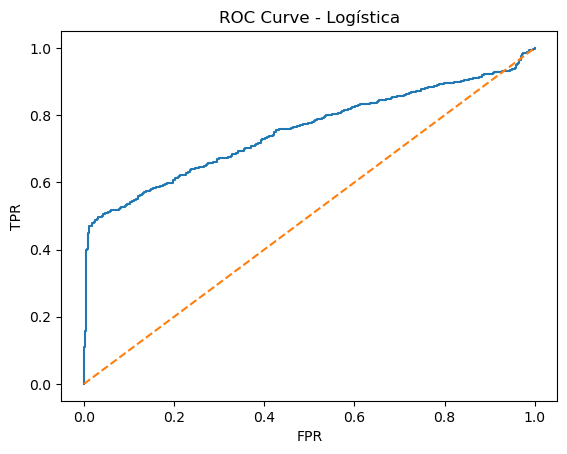

In [74]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Logística")
plt.show()